Compairing key attributes in different images to find similarities. Useful in scene understanding, image stitching, object tracking and pattern recognition.

In [1]:
!pip install opencv-python

In [2]:
import cv2
import numpy as np

In [5]:
import urllib.request

# Download two sample images
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png",
    "img1.jpg"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png",
    "img2.jpg"
)

# Load images
img1 = cv2.imread("img1.jpg")
img2 = cv2.imread("img2.jpg")


In [6]:
# Brute force with SIFT
sift=cv2.SIFT_create()

In [7]:
# Find keypoints and descriptors with SIFT

kp1,des1=sift.detectAndCompute(img1,None)
kp2,des2=sift.detectAndCompute(img2,None)

In [8]:
# Find matches using k nearest neighbours

bf=cv2.BFMatcher()
matches=bf.knnMatch(des1,des2,k=2)

In [9]:
# apply ratio test to threshold the best matches

good=[]
for m,n in matches:
  if m.distance<0.75 *n.distance:
    good.append([m])

array([[[ 21,  21,  21],
        [ 18,  18,  18],
        [ 25,  25,  25],
        ...,
        [127, 127, 127],
        [126, 126, 126],
        [129, 129, 129]],

       [[ 22,  22,  22],
        [ 20,  20,  20],
        [ 18,  18,  18],
        ...,
        [127, 127, 127],
        [127, 127, 127],
        [128, 128, 128]],

       [[ 18,  18,  18],
        [ 20,  20,  20],
        [ 12,  12,  12],
        ...,
        [128, 128, 128],
        [128, 128, 128],
        [128, 128, 128]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 57,  57,  57],
        [ 55,  55,  55],
        [ 49,  49,  49]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 63,  63,  63],
        [ 61,  61,  61],
        [ 54,  54,  54]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 50,  50,  50],
        [ 51,  51,  51],
        [ 59,  59,  59]]], dtype=uint8)
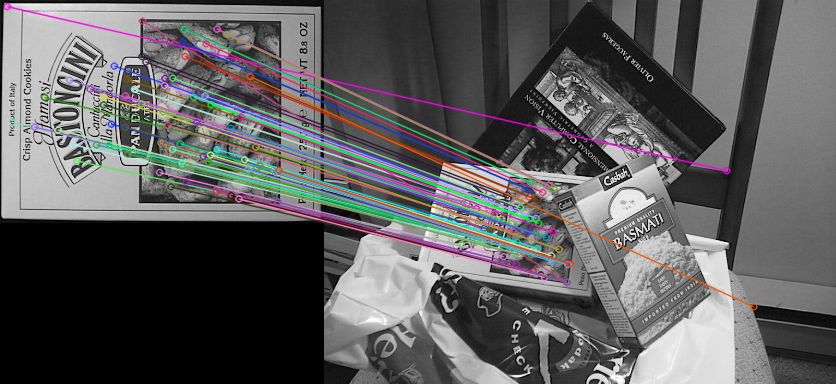

In [11]:
# Draw the matches
img3=cv2.drawMatchesKnn(img1,kp1,img2,kp2,good, None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
img3

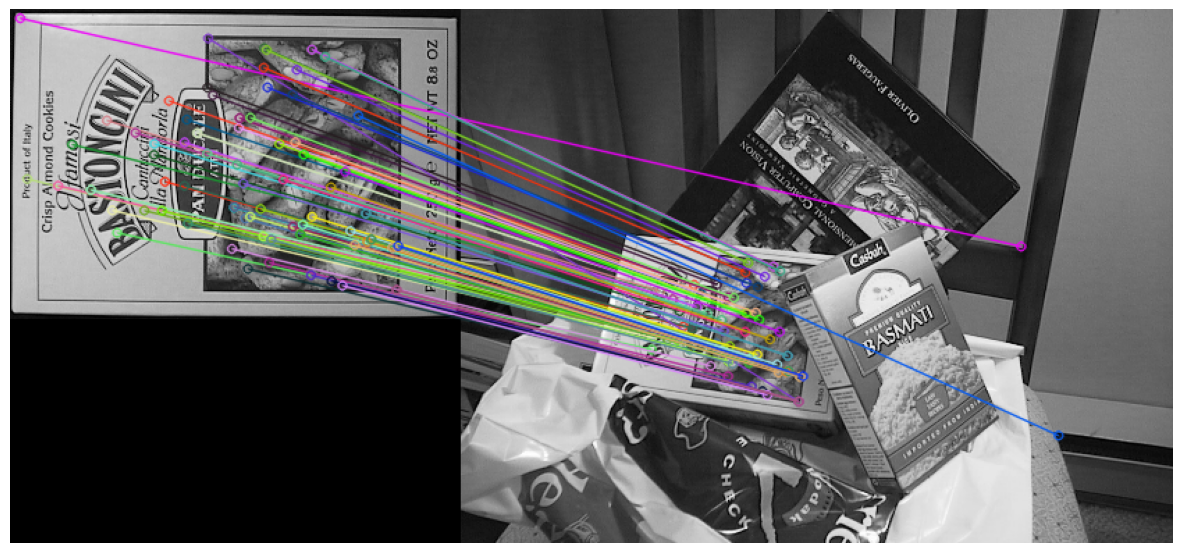

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

1. SIFT finds interesting points in each image — corners, edges, distinctive patterns.
2. It creates a descriptor for each point, basically a numerical fingerprint.
3. BFMatcher compares those fingerprints between the two images.
4. The ratio test removes weak/unreliable matches.

In [18]:
# Brute force with ORB (binary descriptors)

orb=cv2.ORB_create()

kp1,des1=orb.detectAndCompute(img1,None)
kp2,des=orb.detectAndCompute(img2,None)


# Binary descriptor matches using Hamming Distance, which is a measure of the difference between two strings of equal length.

In [21]:
print(des1.shape, des1.dtype)
print(des2.shape, des2.dtype)

(453, 32) uint8
(969, 128) float32


In [22]:
bf=cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [28]:
# matches
matches=bf.match(des1,des2)

# Sort them in order
matches=sorted(matches,key=lambda x:x.distance)

In [30]:
# Draw first n matches
img3=cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:10],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

array([[[ 21,  21,  21],
        [ 18,  18,  18],
        [ 25,  25,  25],
        ...,
        [127, 127, 127],
        [126, 126, 126],
        [129, 129, 129]],

       [[ 22,  22,  22],
        [ 20,  20,  20],
        [ 18,  18,  18],
        ...,
        [127, 127, 127],
        [127, 127, 127],
        [128, 128, 128]],

       [[ 18,  18,  18],
        [ 20,  20,  20],
        [ 12,  12,  12],
        ...,
        [128, 128, 128],
        [128, 128, 128],
        [128, 128, 128]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 57,  57,  57],
        [ 55,  55,  55],
        [ 49,  49,  49]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 63,  63,  63],
        [ 61,  61,  61],
        [ 54,  54,  54]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 50,  50,  50],
        [ 51,  51,  51],
        [ 59,  59,  59]]], dtype=uint8)
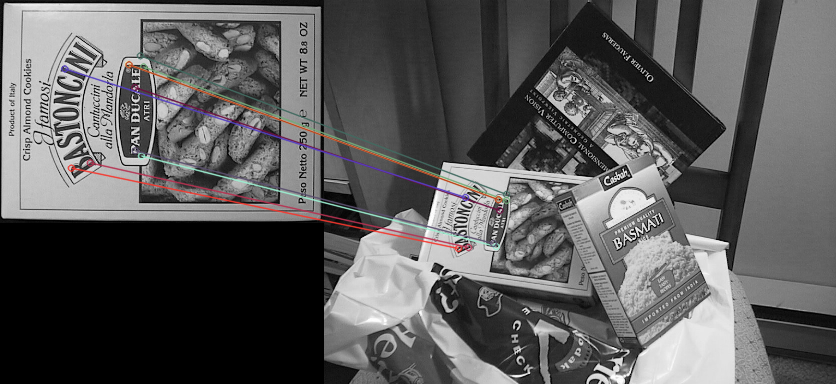

In [31]:
img3

# FLANN : Fast Library for Approximate Nearest Neighbour

It uses clever tricks to figure out which pieces are most likely to go together.  It uses k-d trees, organizing puzzle in special way. It arranges in tree like structure that makes finding much faster. Balancing speed and accuracy in finding matching features, FLANN substantially improves query time.

In [32]:
# we create dictionary to specify the algorithm we use, For SIFT or SURF it looks like

FLANN_INDEX_KDTREE=1
index_params=dict(algorithm=FLANN_INDEX_KDTREE,trees=5)


In [33]:
# For ORB, use the parameters from the paper

FLANN_INDEX_LSH=6
index_params=dict(
    algorithm=FLANN_INDEX_LSH,
    table_number=12,
    key_size=20,
    multi_probe_level=2
)

In [36]:
search_paramas=dict(checks=50)

# initiate SIFT detector
sift=cv2.SIFT_create()

kp1,des1=sift.detectAndCompute(img1,None)
kp2,des2=sift.detectAndCompute(img2,None)

In [38]:
# define thre FLANN parameters. Here, trees is the number of bins we want.

FLANN_INDEX_KDTREE=1
index_params=dict(algorithm=FLANN_INDEX_KDTREE,trees=5)
search_params=dict(checks=50)
flann=cv2.FlannBasedMatcher(index_params,search_params)

matches=flann.knnMatch(des1,des2,k=2)

In [39]:
# draw good matches, so creating mask

matchesMask=[[0,0] for i in range(len(matches))]

In [40]:
# perform ratio test

for i, (m,n) in enumerate(matches):
  if m.distance<0.7*n.distance:
    matchesMask[i]=[1,0]

array([[[ 21,  21,  21],
        [ 18,  18,  18],
        [ 25,  25,  25],
        ...,
        [127, 127, 127],
        [126, 126, 126],
        [129, 129, 129]],

       [[ 22,  22,  22],
        [ 20,  20,  20],
        [ 18,  18,  18],
        ...,
        [127, 127, 127],
        [127, 127, 127],
        [128, 128, 128]],

       [[ 18,  18,  18],
        [ 20,  20,  20],
        [ 12,  12,  12],
        ...,
        [128, 128, 128],
        [128, 128, 128],
        [128, 128, 128]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 57,  57,  57],
        [ 55,  55,  55],
        [ 49,  49,  49]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 63,  63,  63],
        [ 61,  61,  61],
        [ 54,  54,  54]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 50,  50,  50],
        [ 51,  51,  51],
        [ 59,  59,  59]]], dtype=uint8)
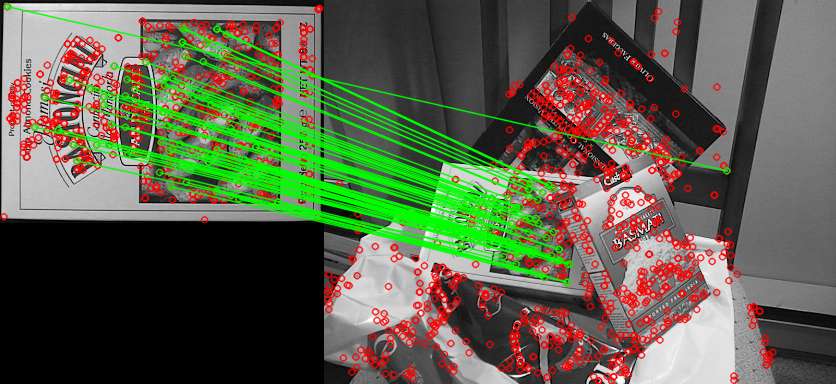

In [43]:
# Visualization of match

draw_params=dict(
    matchColor=(0,255,0),
    singlePointColor=(255,0,0),
    matchesMask=matchesMask,
    flags=cv2.DrawMatchesFlags_DEFAULT,
    )

img3=cv2.drawMatchesKnn(img1,kp1,img2,kp2,matches, None, **draw_params)
img3

## Local Feature Matching with Transformers (LoFTR)

lowe’s ratio test does: for every feature in image 1, FLANN gives us the two closest matches in image 2 (k=2). We compare their distances using m.distance < 0.7 * n.distance. If the first match is significantly better than the second, we keep it as a good match; otherwise, we throw it away. In simple terms: “Keep the match only when the best answer is clearly better than the runner-up.” This helps remove random or incorrect matches and makes the lines you eventually draw between the two images much more reliable.

we can use `Kornia` to find matching features in two images using LoFTR.

In [5]:
!pip install kornia kornia-rs kornia_moons opencv-python --upgrade


In [10]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches

In [15]:
import urllib.request

# Download two sample images
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png",
    "img1.png"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box_in_scene.png",
    "img2.png"
)

# Load images
img1 = cv2.imread("img1.png")
img2 = cv2.imread("img2.png")


In [17]:
from kornia.feature import LoFTR

img_1 = K.io.load_image("img1.png", K.io.ImageLoadType.RGB32)[None, ...]
img_2 = K.io.load_image("img2.png", K.io.ImageLoadType.RGB32)[None, ...]

img_1 = K.geometry.resize(img_1, (512, 512), antialias=True)
img_2 = K.geometry.resize(img_2, (512, 512), antialias=True)

In [18]:
matcher=LoFTR(pretrained="outdoor")



Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 17.6MB/s]


In [20]:
# LOftr works only on grayscale images, so convert

input_dict={
    "image0":K.color.rgb_to_grayscale(img_1),
    "image1":K.color.rgb_to_grayscale(img_2)
}


In [21]:
with torch.inference_mode():
  correspondences=matcher(input_dict)

In [22]:
# cleaning up correspondences using Random sample consensus (RANSC) helps to deal noise or outliers in data

mkpts0=correspondences["keypoints0"].cpu().numpy()
mkpts1=correspondences["keypoints1"].cpu().numpy()
Fm,inliers=cv2.findFundamentalMat(mkpts0,mkpts1,cv2.USAC_MAGSAC,0.5,0.999,100000)
inliers=inliers>0

/tmp/ipykernel_26938/1668894830.py:15: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img_1),
/tmp/ipykernel_26938/1668894830.py:16: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img_2),
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


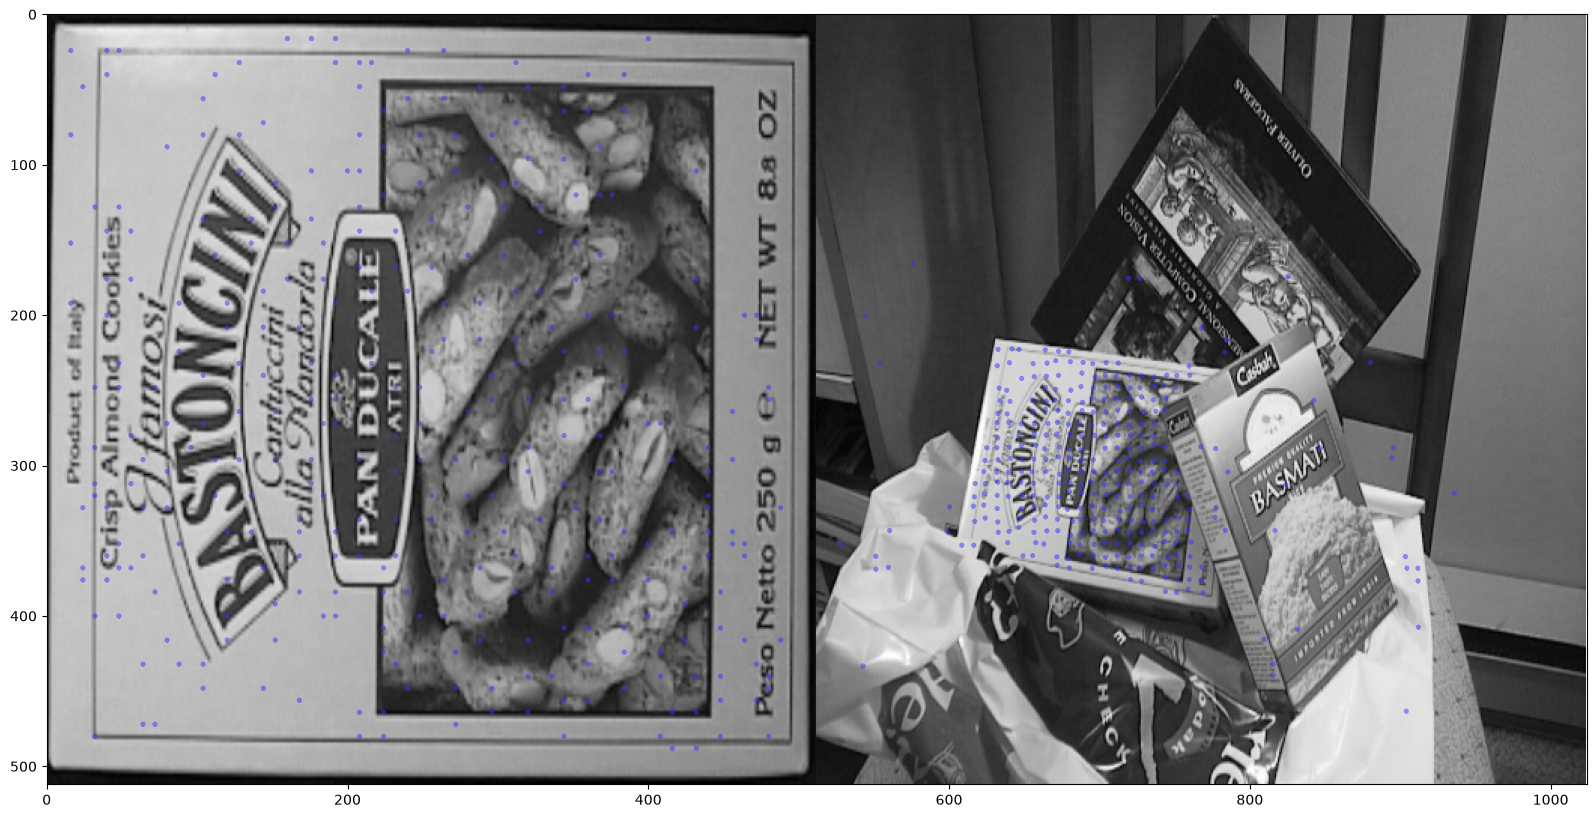

In [26]:
# we can visualize

draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1,-1,2),
        torch.ones(mkpts0.shape[0]).view(1,-1,1,1),
        torch.ones(mkpts0.shape[0]).view(1,-1,1),
    ),
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1,-1,2),
        torch.ones(mkpts1.shape[0]).view(1,-1,1,1),
        torch.ones(mkpts1.shape[0]).view(1,-1,1)
    ),
    torch.arange(mkpts0.shape[0]).view(-1,1).repeat(1,2),
    K.tensor_to_image(img_1),
    K.tensor_to_image(img_2),
    inliers,
    draw_dict={
        "inliner_color":(0.1,1,0.1,0.5),
        "tentative_color":None,
        "feature_color":(0.2,0.2,1,0.5),
        "vertical": False,
    },
)

Feature extraction enables machines to interpret and process visual data like humans. The vital process finds application in diverse fields, impacting daily lives.

`Facial recognition, Object Tracking and Anamoly detection` are areas where feature extraction have great contribution.  

1. Facial recognition: Identifies people using facial features such as eye distance, nose shape and jawline.
- Traditional : Geometric feature extraction
- Modern : Deep Learning/CNNs

Application: Security, Smartphones, healthcare and so on.

Examples: Dubai airport, Iphone, Faceid etc


2. Object Tracking : Detect and follows an object continiously across video frames.
- Color tracking
- Kalman filters
- CNN based trackers

Application; Automative safety, Sports and wildlife conservation
Examples: Tesla, Autopilot, Traptag

3.  Anamoly Detection: Find Visual patterns that deviate from normal.
- Statistical Method
- Neural Nets
- Autoencoders trained on normal data

Applications: Public Safety, Industrial Quality control, Healthcare diagnostics

Examples: London CCTV, BMW defect detection,Zebra Medical Vision

➡️ Feature extraction = finding useful visual information so computer vision systems can understand images/videos.